# Game-Grouped Out-of-Fold Receiver Reliability

The earlier receiver split-half diagnostic used only a small validation subset and had too few qualifying receivers to say much. This experiment generates a prediction for every WR route from a model that did not train on that route's game. Five folds are assigned within each week, and static and dynamic ridge models use identical folds.

To test whether route residuals translate into stable player evaluations, the out-of-fold routes are also divided into two disjoint, week-balanced sets of games. We correlate each qualifying receiver's mean SOE between halves. A receiver must have at least 20 WR routes in each half. Bootstrap intervals resample receivers and describe uncertainty in this dataset; they do not establish season-to-season stability.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from separation_over_expected.reports import read_csv_rows

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "dynamic_features" / "cross_validation"
predictions = read_csv_rows(OUTPUT_DIR / "route_level_oof_predictions_wr.csv")
metrics = read_csv_rows(OUTPUT_DIR / "oof_metrics_wr.csv")
player_halves = read_csv_rows(OUTPUT_DIR / "receiver_oof_half_scores_wr.csv")
reliability = read_csv_rows(OUTPUT_DIR / "receiver_oof_reliability_wr.csv")
len(predictions), len(metrics), len(player_halves), reliability

(20415, 12, 115, [{'comparison': 'ridge_context', 'eligible_receivers': '115', 'pearson': '0.430880', 'spearman': '0.220556', 'pearson_ci_lower': '0.071785', 'pearson_ci_upper': '0.672905', 'spearman_ci_lower': '0.032200', 'spearman_ci_upper': '0.386949', 'minimum_routes_each_half': '20'}, {'comparison': 'ridge_dynamic_context', 'eligible_receivers': '115', 'pearson': '0.451857', 'spearman': '0.209469', 'pearson_ci_lower': '0.079452', 'pearson_ci_upper': '0.691667', 'spearman_ci_lower': '0.022494', 'spearman_ci_upper': '0.384713', 'minimum_routes_each_half': '20'}, {'comparison': 'dynamic_minus_static_pearson', 'eligible_receivers': '115', 'pearson': '0.020977', 'spearman': '-0.011087', 'pearson_ci_lower': '-0.032642', 'pearson_ci_upper': '0.053513', 'spearman_ci_lower': '-0.077042', 'spearman_ci_upper': '0.051544', 'minimum_routes_each_half': '20'}])

## Verify out-of-game coverage

Every WR route should appear exactly once, every game should map to one fold, and both folds and reliability halves should cover all weeks. This confirms the unit kept together during model splitting was the game, not the route.

In [2]:
from collections import Counter, defaultdict

route_keys = [(r["gameId"], r["playId"], r["nflId"]) for r in predictions]
folds_by_game = defaultdict(set)
halves_by_game = defaultdict(set)
for row in predictions:
    folds_by_game[(row["week"], row["gameId"])].add(row["fold"])
    halves_by_game[(row["week"], row["gameId"])].add(row["reliability_half"])
integrity = {
    "oof_routes": len(predictions),
    "unique_route_keys": len(set(route_keys)),
    "games": len(folds_by_game),
    "games_in_multiple_folds": sum(len(value) != 1 for value in folds_by_game.values()),
    "games_in_multiple_reliability_halves": sum(len(value) != 1 for value in halves_by_game.values()),
    "routes_by_fold": dict(sorted(Counter(r["fold"] for r in predictions).items())),
    "routes_by_reliability_half": dict(sorted(Counter(r["reliability_half"] for r in predictions).items())),
    "games_by_reliability_half": {half: len({r["gameId"] for r in predictions if r["reliability_half"] == half}) for half in ("A", "B")},
    "weeks": sorted({int(r["week"]) for r in predictions}),
}
integrity

{'oof_routes': 20415, 'unique_route_keys': 20415, 'games': 122, 'games_in_multiple_folds': 0, 'games_in_multiple_reliability_halves': 0, 'routes_by_fold': {'1': 4972, '2': 3942, '3': 4066, '4': 3589, '5': 3846}, 'routes_by_reliability_half': {'A': 9889, 'B': 10526}, 'games_by_reliability_half': {'A': 62, 'B': 60}, 'weeks': [1, 2, 3, 4, 5, 6, 7, 8]}

## Out-of-fold route prediction

Each row below is scored only by a model trained on the other four folds. The overall row aggregates all held-out predictions. Fold-to-fold variation shows how sensitive route prediction is to which games are held out.

In [3]:
fold_metrics = [r for r in metrics if r["fold"] != "OOF_ALL"]
overall_metrics = [r for r in metrics if r["fold"] == "OOF_ALL"]
fold_metrics, overall_metrics

([{'fold': '1', 'model': 'ridge_context', 'mae': '1.363', 'rmse': '1.853', 'r2': '0.496', 'bias': '0.011', 'mean_actual': '-2.276', 'mean_predicted': '-2.287', 'n': '4972'}, {'fold': '1', 'model': 'ridge_dynamic_context', 'mae': '1.335', 'rmse': '1.826', 'r2': '0.511', 'bias': '0.011', 'mean_actual': '-2.276', 'mean_predicted': '-2.287', 'n': '4972'}, {'fold': '2', 'model': 'ridge_context', 'mae': '1.409', 'rmse': '1.906', 'r2': '0.503', 'bias': '-0.096', 'mean_actual': '-2.583', 'mean_predicted': '-2.487', 'n': '3942'}, {'fold': '2', 'model': 'ridge_dynamic_context', 'mae': '1.377', 'rmse': '1.875', 'r2': '0.519', 'bias': '-0.084', 'mean_actual': '-2.583', 'mean_predicted': '-2.499', 'n': '3942'}, {'fold': '3', 'model': 'ridge_context', 'mae': '1.356', 'rmse': '1.858', 'r2': '0.520', 'bias': '-0.036', 'mean_actual': '-2.387', 'mean_predicted': '-2.351', 'n': '4066'}, {'fold': '3', 'model': 'ridge_dynamic_context', 'mae': '1.333', 'rmse': '1.831', 'r2': '0.534', 'bias': '-0.037', 'mean

## Receiver SOE stability

Receiver SOE is mean route residual within each game half. Positive SOE means the receiver's routes produced more snap-to-release separation change than the model expected, averaged over those routes. Pearson correlation describes agreement in levels; Spearman describes agreement in ranking. The paired bootstrap difference compares dynamic and static Pearson stability on the same receivers.

In [4]:
reliability

[{'comparison': 'ridge_context', 'eligible_receivers': '115', 'pearson': '0.430880', 'spearman': '0.220556', 'pearson_ci_lower': '0.071785', 'pearson_ci_upper': '0.672905', 'spearman_ci_lower': '0.032200', 'spearman_ci_upper': '0.386949', 'minimum_routes_each_half': '20'}, {'comparison': 'ridge_dynamic_context', 'eligible_receivers': '115', 'pearson': '0.451857', 'spearman': '0.209469', 'pearson_ci_lower': '0.079452', 'pearson_ci_upper': '0.691667', 'spearman_ci_lower': '0.022494', 'spearman_ci_upper': '0.384713', 'minimum_routes_each_half': '20'}, {'comparison': 'dynamic_minus_static_pearson', 'eligible_receivers': '115', 'pearson': '0.020977', 'spearman': '-0.011087', 'pearson_ci_lower': '-0.032642', 'pearson_ci_upper': '0.053513', 'spearman_ci_lower': '-0.077042', 'spearman_ci_upper': '0.051544', 'minimum_routes_each_half': '20'}]

In [5]:
player_comparison = []
for row in player_halves:
    player_comparison.append({
        "receiver": row["displayName"],
        "routes_A": row["routes_ridge_dynamic_context_A"],
        "routes_B": row["routes_ridge_dynamic_context_B"],
        "static_A": row["mean_soe_ridge_context_A"],
        "static_B": row["mean_soe_ridge_context_B"],
        "dynamic_A": row["mean_soe_ridge_dynamic_context_A"],
        "dynamic_B": row["mean_soe_ridge_dynamic_context_B"],
    })
player_comparison

[{'receiver': 'Emmanuel Sanders', 'routes_A': '78', 'routes_B': '126', 'static_A': '-0.10210697', 'static_B': '0.23547143', 'dynamic_A': '-0.05907951', 'dynamic_B': '0.28296777'}, {'receiver': 'Antonio Brown', 'routes_A': '77', 'routes_B': '50', 'static_A': '0.33782464', 'static_B': '-0.14889303', 'dynamic_A': '0.24658713', 'dynamic_B': '-0.11230929'}, {'receiver': 'A.J. Green', 'routes_A': '81', 'routes_B': '97', 'static_A': '-0.04310337', 'static_B': '-0.06207229', 'dynamic_A': '-0.05084563', 'dynamic_B': '-0.09709103'}, {'receiver': 'Randall Cobb', 'routes_A': '69', 'routes_B': '37', 'static_A': '-0.17739018', 'static_B': '0.34933842', 'dynamic_A': '-0.22241170', 'dynamic_B': '0.40826492'}, {'receiver': 'Mohamed Sanu', 'routes_A': '85', 'routes_B': '27', 'static_A': '0.32041049', 'static_B': '0.27497596', 'dynamic_A': '0.19333180', 'dynamic_B': '0.16172445'}, {'receiver': 'Marvin Jones', 'routes_A': '83', 'routes_B': '140', 'static_A': '0.20760059', 'static_B': '-0.01516542', 'dynam

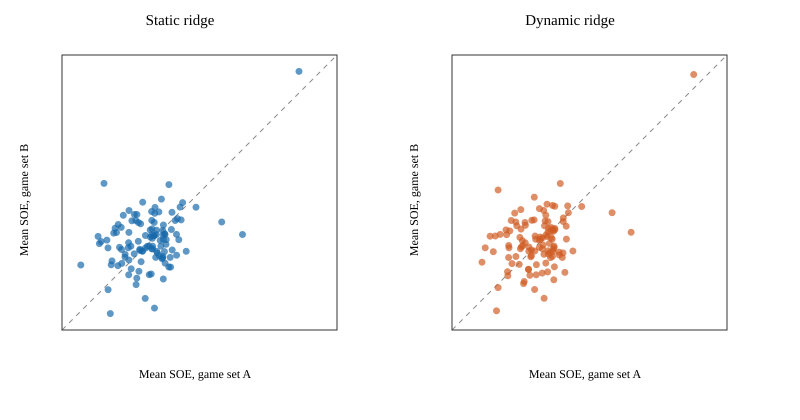

In [6]:
class SVG:
    def __init__(self, markup):
        self.markup = markup
    def _repr_svg_(self):
        return self.markup

values = [float(row[f"mean_soe_{model}_{half}"]) for row in player_halves for model in ("ridge_context", "ridge_dynamic_context") for half in ("A", "B")]
plot_min, plot_max = min(values) - 0.2, max(values) + 0.2
def point_xy(value_x, value_y, left, top, size=330):
    scale = size - 55
    return left + 42 + (value_x - plot_min) / (plot_max - plot_min) * scale, top + 15 + scale - (value_y - plot_min) / (plot_max - plot_min) * scale

panels = []
for panel, model, color in ((0, "ridge_context", "#1769aa"), (1, "ridge_dynamic_context", "#d05b22")):
    left, top = 20 + panel * 390, 40
    size = 330
    dots = []
    for row in player_halves:
        x, y = point_xy(float(row[f"mean_soe_{model}_A"]), float(row[f"mean_soe_{model}_B"]), left, top, size)
        dots.append(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="3.5" fill="{color}" fill-opacity="0.68"/>')
    x0, y0 = point_xy(plot_min, plot_min, left, top, size)
    x1, y1 = point_xy(plot_max, plot_max, left, top, size)
    title = "Static ridge" if panel == 0 else "Dynamic ridge"
    panels.append(f'<text x="{left+160}" y="25" text-anchor="middle" font-size="15">{title}</text><line x1="{x0:.1f}" y1="{y0:.1f}" x2="{x1:.1f}" y2="{y1:.1f}" stroke="#888" stroke-dasharray="5,5"/><rect x="{left+42}" y="{top+15}" width="{size-55}" height="{size-55}" fill="none" stroke="#333"/>{"".join(dots)}<text x="{left+175}" y="{top+size+8}" text-anchor="middle" font-size="12">Mean SOE, game set A</text><text x="{left+8}" y="{top+160}" transform="rotate(-90 {left+8} {top+160})" text-anchor="middle" font-size="12">Mean SOE, game set B</text>')
reliability_scatter = SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="800" height="420" viewBox="0 0 800 420"><rect width="100%" height="100%" fill="white"/>{"".join(panels)}</svg>')
reliability_scatter

## Interpretation

Across 20,415 WR routes, dynamic context modestly improves out-of-fold route prediction (RMSE 1.897 → 1.869; R² 0.493 → 0.508). Both models show positive receiver split-half Pearson stability: 0.431 for static ridge and 0.452 for dynamic ridge, each with wide bootstrap intervals. The paired dynamic-minus-static Pearson difference is only +0.021, and its interval includes zero; Spearman ranking stability does not improve. These results do not show that dynamic features make receiver rankings more reliable.

Route-level OOF scores answer whether dynamic tracking helps predict separation change on unseen games. Receiver split-half correlations answer whether a player's residual average carries across independent samples of games. This is a within-season check on the first eight weeks of 2021; it does not establish year-to-year persistence, and a positive correlation still needs replication on another season.